What was learnt from EDA + Cleaning?
1. The target is imbalanced, so evaluation must focus on Weighted F1 (not accuracy).
2. Financial shocks are strongly linked to worse outcomes.
3. Food insecurity and debt stress are major signals of financial deterioration. 
4. Access to emergency money is protective and separates better-off vs struggling groups.
5. County-level differences are large, so geography matters a lot
6. Monthly income is heavily right-skewed, so log transform is needed before modeling. 
7. Household size behaves non-linearly, so grouped bins are better than raw values.
8. Financial literacy helps, but by itself does not fully protect against worsening outcomes.
9. Some seemingly similar variables are not duplicates and should both be kept as features.



In [11]:
#setup and imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

Data will now be loaded, target column will be 'financial_status'
Class distribution will then be shown below

In [12]:
df = pd.read_csv('finaccess2024_clean.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head(3))

target_col = 'financial_status'
print('Target distribution (%)')
# pick financial_status column, get value counts, normalize to get percentages, multiply by 100, round to 2 decimals, rename the series to '%', and display it
display(df[target_col].value_counts(normalize=True).mul(100).round(2).rename('%'))


Shape: 20,857 rows x 28 columns


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,No barrier,Without Disability
1,Garissa,Urban,Female,Above 55,11,No formal education,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,Primary completed,Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability


Target distribution (%)


financial_status
Worsened           52.60
Stayed the same    26.88
Improved           20.52
Name: %, dtype: float64

In [13]:
# Now, data preprocessing and feature engineering
# Log-transform monthly income to reduce skewness
# create a new feature 'household_size_group' by binning 'household_size' into categories (1-2, 3-4, 5-6, 7+)
# drop the original 'household_size' column.
# Done in a function so that we can apply to both train and test sets to avoid data leakage.

def feature_engineering(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X['monthly_income'] = np.log1p(X['monthly_income'])
    X['household_size_group'] = pd.cut(
        X['household_size'],
        bins=[0, 2, 4, 6, np.inf],
        labels=['1-2', '3-4', '5-6', '7+'],
        include_lowest=True
    ).astype(str)
    X = X.drop(columns=['household_size'])
    return X

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (16685, 27)
Test shape: (4172, 27)


## Preprocessing and Modelling

### Why we used Logistic Regression
It is fast and stable for tabular classification. With `class_weight='balanced'`, it also handles class imbalance better. Its coefficients are interpretable, and it works well with our preprocessing pipeline.

### Why Decision Tree
It captures non-linear relationships and feature interactions that Logistic Regression can miss.

### Why Random Forest
It is a stronger tree-based benchmark that reduces overfitting by averaging many trees, often improving robustness and generalization on tabular data.

In [14]:
# now we can set up our preprocessing pipeline and models
# first, detect numeric and categorical columns after feature engineering
# apply StandardScaler to numeric columns 
# and apply OneHotEncoder to categorical columns
# transform while dropping any remaining columns
# Finally add three baseline models with class_weight='balanced' to handle class imbalance.
X_train_fe = feature_engineering(X_train)
numeric_cols = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_fe.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ],
    remainder='drop'
)

models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1500,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'DecisionTree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_depth=12,
        min_samples_leaf=20
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [15]:
# Now we can fit the models and evaluate them using weighted F1 score
# we now create a pipeline for each model
# then apply feature engineering, preprocessing, and model fitting in one step to avoid data leakage
# predict on the test set
# calculate weighted F1 score and store results in a list of dictionaries
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ('feature_engineering', FunctionTransformer(feature_engineering, validate=False)),
        ('preprocess', preprocess),
        ('model', model),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    wf1 = f1_score(y_test, y_pred, average='weighted')

    results.append({'model': model_name, 'weighted_f1': wf1})
    fitted_pipelines[model_name] = pipe

results_df = pd.DataFrame(results).sort_values('weighted_f1', ascending=False).reset_index(drop=True)
display(results_df)

,model,weighted_f1
0,LogisticRegression,0.515749
1,RandomForest,0.515702
2,DecisionTree,0.463913


Best model: LogisticRegression
Weighted F1: 0.5157

Classification report:
                 precision    recall  f1-score   support

       Improved       0.36      0.58      0.44       856
Stayed the same       0.38      0.36      0.37      1122
       Worsened       0.70      0.55      0.62      2194

       accuracy                           0.51      4172
      macro avg       0.48      0.50      0.48      4172
   weighted avg       0.55      0.51      0.52      4172



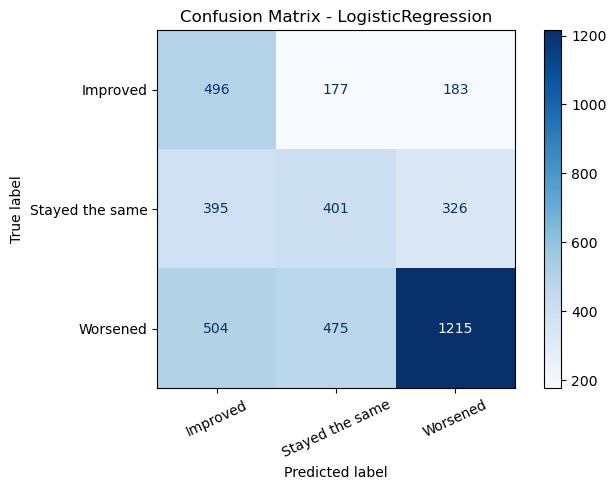

In [16]:
# Then, we pick the best model by picking the highest F1 model
# We can also print the classification report and confusion matrix for the best model to understand its performance in more detail. 

best_model_name = results_df.loc[0, 'model']
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

print(f'Best model: {best_model_name}')
print(f"Weighted F1: {f1_score(y_test, y_pred_best, average='weighted'):.4f}")
print()
print('Classification report:')
print(classification_report(y_test, y_pred_best))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap='Blues', xticks_rotation=25, ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

In [17]:
# Multicollinearity check between nfhi_11 and nfhi_12, then ablation test for model impact
binary_map = {'Yes': 1, 'No': 0}
check_df = X_train[['nfhi_11', 'nfhi_12']].replace(binary_map)
phi_corr = check_df['nfhi_11'].corr(check_df['nfhi_12'])
print(f"Correlation (nfhi_11 vs nfhi_12): {phi_corr:.3f}")
print()

def evaluate_lr_ablation(drop_cols=None):
    drop_cols = drop_cols or []
    X_train_tmp = X_train.drop(columns=drop_cols).copy()
    X_test_tmp = X_test.drop(columns=drop_cols).copy()

    X_train_tmp_fe = feature_engineering(X_train_tmp)
    num_cols = X_train_tmp_fe.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train_tmp_fe.select_dtypes(exclude=[np.number]).columns.tolist()

    preprocess_tmp = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ],
        remainder='drop'
    )

    pipe_tmp = Pipeline(steps=[
        ('feature_engineering', FunctionTransformer(feature_engineering, validate=False)),
        ('preprocess', preprocess_tmp),
        ('model', LogisticRegression(max_iter=1500, class_weight='balanced', random_state=RANDOM_STATE)),
    ])

    pipe_tmp.fit(X_train_tmp, y_train)
    pred_tmp = pipe_tmp.predict(X_test_tmp)
    return f1_score(y_test, pred_tmp, average='weighted')

ablation_df = pd.DataFrame([
    {'scenario': 'Baseline (all features)', 'weighted_f1': evaluate_lr_ablation([])},
    {'scenario': 'Drop nfhi_11', 'weighted_f1': evaluate_lr_ablation(['nfhi_11'])},
    {'scenario': 'Drop nfhi_12', 'weighted_f1': evaluate_lr_ablation(['nfhi_12'])},
    {'scenario': 'Drop both nfhi_11 and nfhi_12', 'weighted_f1': evaluate_lr_ablation(['nfhi_11', 'nfhi_12'])},
]).sort_values('weighted_f1', ascending=False).reset_index(drop=True)

display(ablation_df)

Correlation (nfhi_11 vs nfhi_12): 0.337



,scenario,weighted_f1
0,Drop nfhi_12,0.517543
1,Baseline (all features),0.515749
2,Drop nfhi_11,0.510892
3,Drop both nfhi_11 and nfhi_12,0.510709


,feature,importance
0,cat__county_Garissa,0.773696
1,cat__county_West Pokot,0.465095
2,cat__county_Baringo,0.458792
3,cat__county_Tana River,0.402971
4,cat__county_Marsabit,0.369764
5,cat__county_Kisumu,0.357833
6,cat__county_Turkana,0.350286
7,cat__county_Wajir,0.339347
8,cat__marital_status_Unknown,0.335624
9,cat__county_Bungoma,0.319324


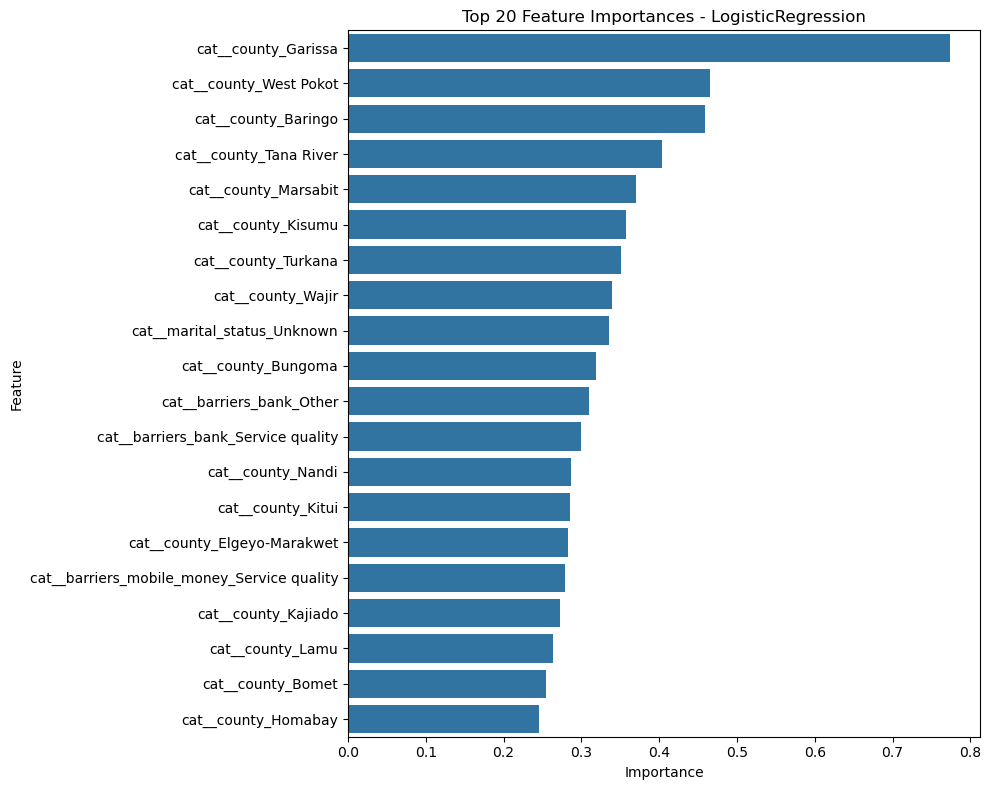

In [18]:
# Finally, we can also look at feature importance for the best model to understand which features influential in predicting financial status.
feature_names = best_pipe.named_steps['preprocess'].get_feature_names_out()
model_obj = best_pipe.named_steps['model']

if hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
elif hasattr(model_obj, 'coef_'):
    importances = np.mean(np.abs(model_obj.coef_), axis=0)
else:
    raise ValueError('This model does not expose coefficients or feature importances.')

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n = 20
display(importance_df.head(top_n))

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(top_n), y='feature', x='importance', color='#1f77b4')
plt.title(f'Top {top_n} Feature Importances - {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Top features by total (summed) importance:


,parent_feature,importance_sum,encoded_columns,importance_mean
0,county,10.021972,47,0.213233
1,barriers_bank,1.423636,10,0.142364
2,barriers_mobile_money,1.079326,10,0.107933
3,Age,0.879306,6,0.146551
4,marital_status,0.672843,5,0.134569
5,education_level,0.593007,9,0.065890
6,fl_score,0.301366,4,0.075341
7,formal_service_use,0.209132,2,0.104566
8,accessto_13k_1month,0.190565,2,0.095282
9,mobile_money_access,0.177567,2,0.088783


Top features by mean importance per encoded column (fairness check):


,parent_feature,importance_mean,encoded_columns,importance_sum
0,county,0.213233,47,10.021972
1,Age,0.146551,6,0.879306
2,barriers_bank,0.142364,10,1.423636
3,monthly_income,0.136887,1,0.136887
4,marital_status,0.134569,5,0.672843
5,barriers_mobile_money,0.107933,10,1.079326
6,formal_service_use,0.104566,2,0.209132
7,accessto_13k_1month,0.095282,2,0.190565
8,mobile_money_access,0.088783,2,0.177567
9,nfhi_11,0.088329,2,0.176659


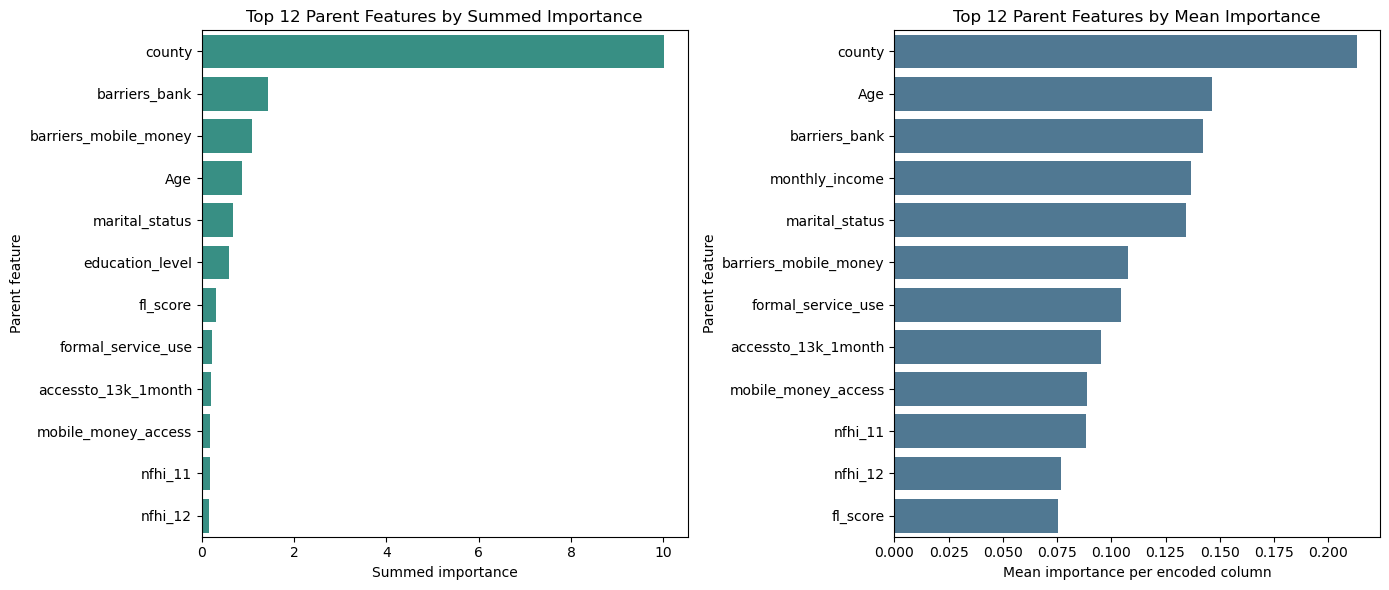

In [19]:
# Group one-hot feature importance into parent features
# We report both total importance (sum) and fair importance (mean per encoded column).
grouped_importance = importance_df.copy()

def infer_parent_feature(feature_name: str) -> str:
    # Numeric features keep their original names after removing the transformer prefix
    if feature_name.startswith('num__'):
        return feature_name.replace('num__', '', 1)

    # For one-hot encoded categoricals, map each encoded column back to the source column
    if feature_name.startswith('cat__'):
        remainder = feature_name.replace('cat__', '', 1)
        for col in sorted(categorical_cols, key=len, reverse=True):
            if remainder.startswith(f'{col}_'):
                return col
        return remainder

    return feature_name

grouped_importance['parent_feature'] = grouped_importance['feature'].apply(infer_parent_feature)

grouped_summary = (
    grouped_importance.groupby('parent_feature', as_index=False)
    .agg(
        importance_sum=('importance', 'sum'),
        encoded_columns=('importance', 'size'),
        importance_mean=('importance', 'mean')
    )
    .sort_values('importance_sum', ascending=False)
    .reset_index(drop=True)
)

top_k = 12
print('Top features by total (summed) importance:')
display(grouped_summary[['parent_feature', 'importance_sum', 'encoded_columns', 'importance_mean']].head(top_k))

print('Top features by mean importance per encoded column (fairness check):')
display(
    grouped_summary.sort_values('importance_mean', ascending=False)
    [['parent_feature', 'importance_mean', 'encoded_columns', 'importance_sum']]
    .head(top_k)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: sum-based ranking (can favor high-cardinality features)
sum_top = grouped_summary.head(top_k)
sns.barplot(data=sum_top, y='parent_feature', x='importance_sum', color='#2a9d8f', ax=axes[0])
axes[0].set_title(f'Top {top_k} Parent Features by Summed Importance')
axes[0].set_xlabel('Summed importance')
axes[0].set_ylabel('Parent feature')

# Plot 2: mean-based ranking (fairer across different cardinalities)
mean_top = grouped_summary.sort_values('importance_mean', ascending=False).head(top_k)
sns.barplot(data=mean_top, y='parent_feature', x='importance_mean', color='#457b9d', ax=axes[1])
axes[1].set_title(f'Top {top_k} Parent Features by Mean Importance')
axes[1].set_xlabel('Mean importance per encoded column')
axes[1].set_ylabel('Parent feature')

plt.tight_layout()
plt.show()

## Conclusions

### Model Performance
1. Three benchmark models were compared using Weighted F1: Logistic Regression, RandomForest, and DecisionTree.
2. Logistic Regression remains the best baseline in this run (Weighted F1 = 0.5170), narrowly ahead of RandomForest (0.5157); DecisionTree is lower (0.4639).
3. Class-level performance is uneven: the model predicts `Worsened` better than `Stayed the same`.

### Feature and Collinearity Checks
1. The `nfhi_11` and `nfhi_12` collinearity concern is addressed through correlation inspection and ablation testing.
2. Feature-importance analysis is presented at two levels:
   - Encoded feature level (raw one-hot columns).
   - Parent-feature level (grouped interpretation).
3. Grouped importance includes both total importance and mean importance per encoded column to reduce high-cardinality bias (for example `county`).

### Interpretation Summary
1. Geography (`county`) remains a strong predictor of financial outcomes.
2. Access and service barriers are influential, suggesting affordability and service quality matter.
3. Financial health indicators (`nfhi_11`, `nfhi_13`, `accessto_13k_1month`) remain policy-relevant drivers.



=== TOP PARENT FEATURES BY SUMMED IMPORTANCE ===
           parent_feature  importance_sum  encoded_columns  importance_mean
0                  county       10.021972               47         0.213233
1           barriers_bank        1.423636               10         0.142364
2   barriers_mobile_money        1.079326               10         0.107933
3                     Age        0.879306                6         0.146551
4          marital_status        0.672843                5         0.134569
5         education_level        0.593007                9         0.065890
6                fl_score        0.301366                4         0.075341
7      formal_service_use        0.209132                2         0.104566
8     accessto_13k_1month        0.190565                2         0.095282
9     mobile_money_access        0.177567                2         0.088783
10                nfhi_11        0.176659                2         0.088329
11                nfhi_12        0.1533

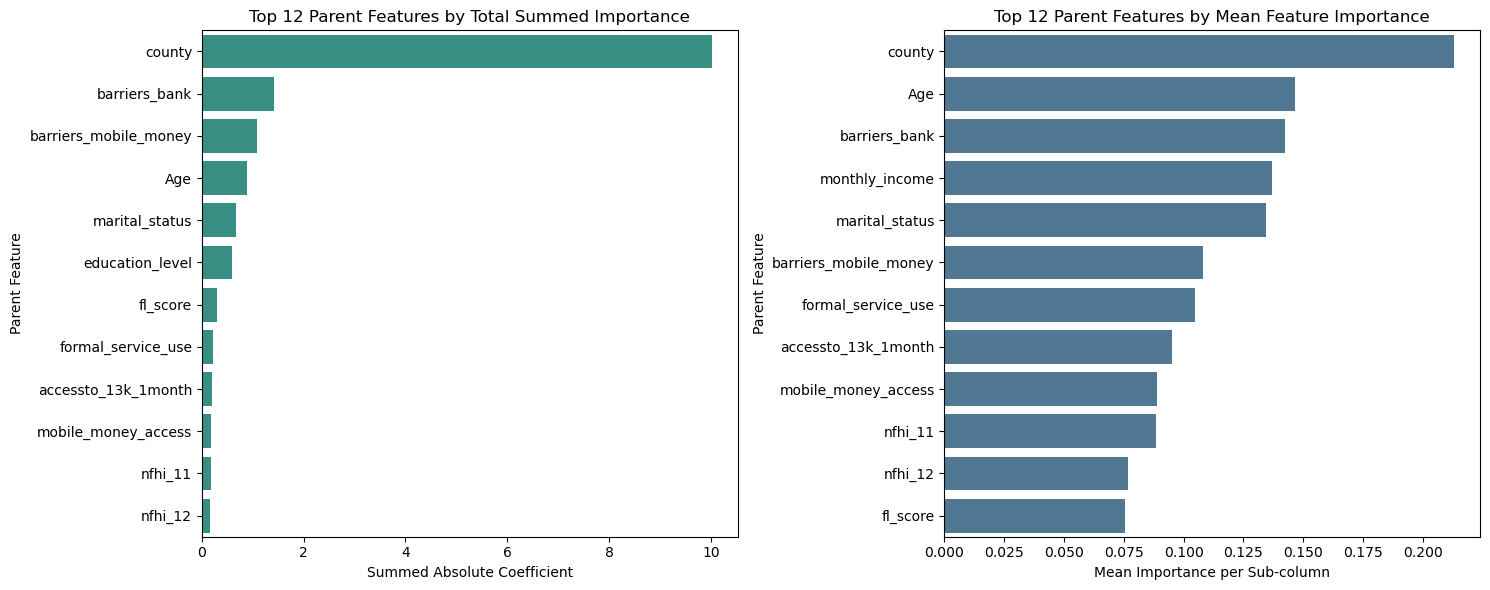

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Extract feature names from the preprocessor step and coefficients from the model
feature_names = best_pipe.named_steps['preprocess'].get_feature_names_out()
model_obj = best_pipe.named_steps['model']

# Since Logistic Regression was the best model, we extract coefficients. 
# We use the mean absolute coefficient across the 3 target classes for overall importance.
if hasattr(model_obj, 'coef_'):
    importances = np.mean(np.abs(model_obj.coef_), axis=0)
    raw_coefs = model_obj.coef_  # Kept for class-specific direction analysis
elif hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
    raw_coefs = None
else:
    raise ValueError("The selected best model does not expose coefficients or feature importances.")

#  baseline DataFrame of all one-hot encoded sub-features
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

#  function to map one-hot sub-features back to their parent features
def infer_parent_feature(feature_name: str) -> str:
    if feature_name.startswith('num__'):
        return feature_name.replace('num__', '', 1)
    if feature_name.startswith('cat__'):
        remainder = feature_name.replace('cat__', '', 1)
        # Identify original categorical columns dynamically
        for col in sorted(categorical_cols, key=len, reverse=True):
            if remainder.startswith(f'{col}_'):
                return col
        return remainder
    return feature_name

importance_df['parent_feature'] = importance_df['feature'].apply(infer_parent_feature)

#  Aggregate by Parent Feature (Total Summed and Fair Mean Importance)
grouped_summary = (
    importance_df.groupby('parent_feature', as_index=False)
    .agg(
        importance_sum=('importance', 'sum'),
        encoded_columns=('importance', 'size'),
        importance_mean=('importance', 'mean')
    )
    .sort_values('importance_sum', ascending=False)
    .reset_index(drop=True)
)

print("=== TOP PARENT FEATURES BY SUMMED IMPORTANCE ===")
print(grouped_summary[['parent_feature', 'importance_sum', 'encoded_columns', 'importance_mean']].head(12))

# Extract specific County-level drivers for Slide 5
print("\n=== TOP SPECIFIC COUNTY DRIVERS (HIGHEST RISK ENCODED COEFFICIENTS) ===")
# Filter for encoded county features
county_features = importance_df[importance_df['parent_feature'] == 'county'].copy()

# Map back the raw coefficients specifically targeting the 'Worsened' class
# Assuming the order of classes in best_pipe.classes_ is checked, let's locate the 'Worsened' index
try:
    worsened_idx = list(best_pipe.named_steps['model'].classes_).index('Worsened')
    county_features['coef_worsened'] = county_features['feature'].apply(
        lambda x: raw_coefs[worsened_idx][list(feature_names).index(x)] if raw_coefs is not None else 0
    )
    print(county_features.sort_values('coef_worsened', ascending=False)[['feature', 'importance', 'coef_worsened']].head(5))
except Exception as e:
    print(county_features.head(5))

# Visualization: Plot Parent Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Total Summed Importance (highlights total contribution)
sns.barplot(data=grouped_summary.head(12), y='parent_feature', x='importance_sum', color='#2a9d8f', ax=axes[0])
axes[0].set_title('Top 12 Parent Features by Total Summed Importance')
axes[0].set_xlabel('Summed Absolute Coefficient')
axes[0].set_ylabel('Parent Feature')

# Plot 2: Fair Mean Importance (normalizes high cardinality features like county)
mean_sorted = grouped_summary.sort_values('importance_mean', ascending=False).head(12)
sns.barplot(data=mean_sorted, y='parent_feature', x='importance_mean', color='#457b9d', ax=axes[1])
axes[1].set_title('Top 12 Parent Features by Mean Feature Importance')
axes[1].set_xlabel('Mean Importance per Sub-column')
axes[1].set_ylabel('Parent Feature')

plt.tight_layout()
plt.show()